# A/B Test: Spanish Translation on Conversion Rate

## Challenge Description

Company XYZ is a worldwide e-commerce site with localized versions of the site.
A data scientist at XYZ noticed that Spain-based users have a much higher conversion rate than any other Spanish-speaking country. She therefore went and talked to the international team in charge of Spain And LatAm to see if they had any ideas about why that was happening.

Spain and LatAm country manager suggested that one reason could be translation. All Spanish- speaking countries had the same translation of the site which was written by a Spaniard. They agreed to try a test where each country would have its one translation written by a local. That is, Argentinian users would see a translation written by an Argentinian, Mexican users by a Mexican and so on. Obviously, nothing would change for users from Spain.
After they run the test however, they are really surprised cause the test is negative. I.e., it appears that the non-localized translation was doing better!

You are asked to:
* Confirm that the test is actually negative. That is, it appears that the old version of the site with just one translation across Spain and LatAm performs better
* Explain why that might be happening. Are the localized translations really worse?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

user = pd.read_csv("user_table.csv")
test = pd.read_csv("test_table.csv")
user.shape, test.shape

((452867, 4), (453321, 9))

In [3]:
user.head()

,user_id,sex,age,country
0,765821,M,20,Mexico
1,343561,F,27,Nicaragua
2,118744,M,23,Colombia
3,987753,F,27,Venezuela
4,554597,F,20,Spain


In [5]:
set(user["country"])

{'Argentina',
 'Bolivia',
 'Chile',
 'Colombia',
 'Costa Rica',
 'Ecuador',
 'El Salvador',
 'Guatemala',
 'Honduras',
 'Mexico',
 'Nicaragua',
 'Panama',
 'Paraguay',
 'Peru',
 'Spain',
 'Uruguay',
 'Venezuela'}

In [3]:
test.head()

,user_id,date,source,device,browser_language,ads_channel,browser,conversion,test
0,315281,2015-12-03,Direct,Web,ES,NaN,IE,1,0
1,497851,2015-12-04,Ads,Web,ES,Google,IE,0,1
2,848402,2015-12-04,Ads,Web,ES,Facebook,Chrome,0,0
3,290051,2015-12-03,Ads,Mobile,Other,Facebook,Android_App,0,1
4,548435,2015-11-30,Ads,Web,ES,Google,FireFox,0,1


In [4]:
data = test.merge(user, how='inner', on='user_id')
data = data.query('country != "Spain"') 
data.shape

(401085, 12)

## A/B Test on Conversion Rate

We will use t-test. The null hypothesis is

$$H_0: \ \textrm{popultation 1 and 2 have same conversion rate, i.e. } p_1=p_2$$ 

The alternative hypothesis is 

$$H_a: \ p_1 \ne p_2$$ 


In [5]:
control = data[data.test == 0]
treatment = data[data.test == 1]
control.shape, treatment.shape

((185311, 12), (215774, 12))

In [9]:
control.shape, treatment.shape

((185311, 12), (215774, 12))

In [17]:
control[control.conversion == 1]['conversion'].sum(), treatment[treatment.conversion == 1]['conversion'].sum()

(8949, 9367)

In [13]:
print(control['conversion'].mean(), treatment['conversion'].mean())

0.04829179055749524 0.043411161678422794


In [14]:
print(control['conversion'].std(), treatment['conversion'].std())

0.2143826987826136 0.20378131704133629


In [30]:
t_test = stats.ttest_ind(control["conversion"], treatment["conversion"], equal_var=False)

In [31]:
t_test

Ttest_indResult(statistic=7.353895203080277, pvalue=1.9289178577799033e-13)

Since the p-value is pretty small < 0.05, the statistic result is significant and we can reject the null hypothesis. The control users are converting at 4.8% while users in the test just at 4.3%. That’s a 10% drop, which would be dramatic if it were true. 

Note the most likely reason for weird A/B test results are:
* We didn’t collect enough data
* Some bias has been introduced in the experiment so that test/control people are not really random


## Check A/B Test Randomization

also here the [Randomization solution page](https://productds.com/wp-content/uploads/Randomization.html)

### Data daterange

In [21]:
contr_date = control.groupby(["date"])["conversion"].mean()
treat_date = treatment.groupby(["date"])["conversion"].mean()

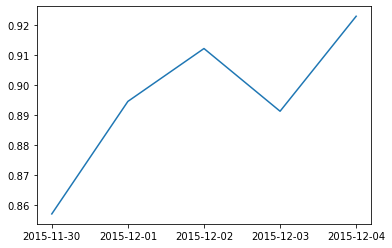

In [26]:
plt.plot(list(contr_date.index), [x/y for x, y in zip(treat_date.values, contr_date.values)])
plt.show()

From the plot, we notice a couple of things:

* Test has constantly been worse than control and there is relatively little variance across days. That probably means that we do have enough data, but there was some bias in the experiment set up

* As a side note, we just ran it for 5 days. We should always run the test for at least 1 full week to capture weekly patterns, 2 weeks would be much better


### Randomization

Checking that randomization worked well simply means making sure that all variables have the same distribution in treatment and control groups. 

For example, taking for instance the first variable, `source`, it would be meaningful checking if proportion of users coming from ads, SEO, and direct is the same:

In [6]:
data_grouped_source = pd.DataFrame()
data_grouped_source['frequency_test_0'] = data[data.test == 0].groupby(["source"])["test"].count()
data_grouped_source['frequency_test_1'] = data[data.test == 1].groupby(["source"])["test"].count()

#get relative frequencies
print(data_grouped_source/data_grouped_source.sum())


        frequency_test_0  frequency_test_1
source                                    
Ads             0.401228          0.400641
Direct          0.200949          0.199500
SEO             0.397823          0.399858


As we can see, relative frequency of source for different segments is the same. That is, we have basically the same proportion of users coming from Ads, Direct, and SEO in both test and control.


We could potentially keep checking all the variables like this. But it would be extremely time consuming (and boring), especially when you start considering numerical variables and categorical variables with many levels.


### Implement ML to identify if randomization


We turn this into a machine learning problem and let an algorithm do the boring work for us. The approach is:

1. Get rid of the `conversion` variable for now. We don’t care about it here. We are just checking if the two user distributions are the same. This is before we check conversion rate for the groups

2. Use the variable `test` as our label. Try to build a model that manages to separate the users whose test value is 0 vs those whose test value is 1. If randomization worked well, this will be impossible because the two groups are exactly the same. If all variable relative frequencies were the same as for source, no model would be able to separate test == 1 vs test == 0. **If randomization did not work well, the model will manage to use a given variable to separate the two groups**.

3. As a model, pick a decision tree. This will allow you to clearly see which variable (if any) is used for the split. That’s where randomization failed.

In [6]:
# import os
# os.environ["PATH"] += '/Users/hsianghsuanhung/Desktop/takehome_challenge/2.Translation_test/'

import os
os.environ["PATH"] += os.pathsep + "/Macintosh HD⁩/anaconda3⁩/lib⁩/⁨python3.7⁩/site-packages⁩/sphinx⁩/templates⁩/graphviz"


In [7]:
import graphviz
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from graphviz import Source
  
data['date'] = data['date'].apply(str)
  
data_dummy = pd.get_dummies(data)
train_cols = data_dummy.drop(['test', 'conversion'], axis=1)

tree=DecisionTreeClassifier(class_weight="balanced", min_impurity_decrease = 0.001)
tree.fit(train_cols, data_dummy['test'])


dot_data = export_graphviz(tree, out_file=None, feature_names=train_cols.columns, proportion=True, rotate=True)

graph = graphviz.Source(dot_data)  
graph

# with open("tree_test.dot") as f:
#     dot_graph = f.read()

# s = Source.from_file("tree_test.dot")
# graphviz.view("tree_test.dot")
# s.view()

ExecutableNotFound: failed to execute 'dot', make sure the Graphviz executables are on your systems' PATH

In [42]:
print(data_dummy.groupby("test")[["country_Argentina", "country_Uruguay"]].mean())

      country_Argentina  country_Uruguay
test                                    
0              0.050488         0.002239
1              0.173223         0.017236


In treatment (test = 1), 17% of users are from Argentina, but in control only 5% of users are from Argentina. Uruguay is even more extreme: test has 1.7% of users from Uruguay and control has just 0.2% of Uruguayan users.


And this is a big problem because that means we are not comparing anymore apples to apples in our A/B test. The difference we might see in conversion rate might very well depend on the fact that users between the two groups are different.

In [43]:
#this is the test results using the orginal dataset
original_data = stats.ttest_ind(data_dummy[data['test'] == 1]['conversion'], 
                                data_dummy[data['test'] == 0]['conversion'], 
                                equal_var=False)
  
#this is after removing Argentina and Uruguay
data_no_AR_UR = stats.ttest_ind(data_dummy[(data['test'] == 1) & 
                                           (data_dummy['country_Argentina'] ==  0) & 
                                           (data_dummy['country_Uruguay'] ==  0)
                                           ]['conversion'], 
                                data_dummy[(data['test'] == 0) & 
                                           (data_dummy['country_Argentina'] ==  0) & 
                                           (data_dummy['country_Uruguay'] ==  0)
                                           ]['conversion'], 
                                equal_var=False)
  
print(
pd.DataFrame({"data_type" : ["Full", "Removed_Argentina_Uruguay"], 
                  "p_value" : [original_data.pvalue, data_no_AR_UR.pvalue],
                  "t_statistic" : [original_data.statistic, data_no_AR_UR.statistic]
                 })
)


                   data_type       p_value  t_statistic
0                       Full  1.928918e-13    -7.353895
1  Removed_Argentina_Uruguay  7.200849e-01     0.358346


The biased test where some countries are over/under represented is statistically significant with negative t statistics. So test is worse than control! After removing those two countries, we get non-significant results.

In [38]:
data_test_country = pd.DataFrame()
data_test_country['country'] = list(data.groupby("country")['conversion'].count().index)

data_test_country['p_value'] = data.groupby("country")['conversion'].agg(p_value=
                                            lambda x: stats.ttest_ind(x[data["test"]==1], 
                                                                      x[data["test"]==0], 
                                                                      equal_var=False
                                                                      ).pvalue).reset_index()['p_value']
data_test_country['conversion_treatment'] = data.groupby("country")['conversion'].agg(conversion_treatment=lambda x: x[data["test"]==1].mean()).reset_index()['conversion_treatment']
data_test_country['conversion_control'] = data.groupby("country")['conversion'].agg(conversion_control=lambda x: x[data["test"]==0].mean()).reset_index()['conversion_control']



print(data_test_country.sort_values(by=['p_value']))
        

        country   p_value  conversion_treatment  conversion_control
9        Mexico  0.165544              0.051186            0.049495
6   El Salvador  0.248127              0.047947            0.053554
2         Chile  0.302848              0.051295            0.048107
0     Argentina  0.335147              0.013725            0.015071
3      Colombia  0.423719              0.050571            0.052089
8      Honduras  0.471463              0.047540            0.050906
7     Guatemala  0.572107              0.048647            0.050643
15    Venezuela  0.573702              0.048978            0.050344
4    Costa Rica  0.687876              0.054738            0.052256
11       Panama  0.705327              0.049370            0.046796
1       Bolivia  0.718885              0.047901            0.049369
13         Peru  0.771953              0.050604            0.049914
10    Nicaragua  0.780400              0.054177            0.052647
14      Uruguay  0.879764              0.012907 

After we control for country, the test clearly appears non significant. Not a great success given that the goal was to improve conversion rate, but at least we know that a localized translation didn’t make things worse!


At this point, you have two options:


Acknowledge that there was a bug, go talk to the software engineer in charge of randomization, figure out what went wrong, fix it and re-run the test. Note that when you find a bug, it might be a sign that more things are messed up, not just the one you found. So when you find a bug, always try to get to the bottom of it


If you do find out that everything else was fine, but for some reason there was only a problem with those two countries, you can potentially adjust the weights for those two segments so that relative frequencies become the same and then re-check the test results

